<a href="https://colab.research.google.com/github/tsarangler/ECON3916-Statistical-Machine-Learning/blob/main/Project%201/ECON3916%3A%20P1P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 2.1: Establishing the "Digital Portfolio"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

url = 'https://raw.githubusercontent.com/tsarangler/ECON3916-Statistical-Machine-Learning/refs/heads/main/data/njmin3.csv'
df = pd.read_csv(url)

# Step 2.2: Ingestion and "Dirty Data" Forensics

In [2]:
# Task 1: The Shape and Types Audit

print(df.shape)
df.info()

(820, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nj        820 non-null    int64  
 1   d         820 non-null    int64  
 2   d_nj      820 non-null    int64  
 3   fte       794 non-null    float64
 4   bk        820 non-null    int64  
 5   kfc       820 non-null    int64  
 6   roys      820 non-null    int64  
 7   wendys    820 non-null    int64  
 8   co_owned  820 non-null    int64  
 9   centralj  820 non-null    int64  
 10  southj    820 non-null    int64  
 11  pa1       820 non-null    int64  
 12  pa2       820 non-null    int64  
 13  demp      768 non-null    float64
dtypes: float64(2), int64(12)
memory usage: 89.8 KB


In [3]:
df.describe()

,nj,d,d_nj,fte,bk,kfc,roys,wendys,co_owned,centralj,southj,pa1,pa2,demp
count,820.000000,820.000000,820.000000,794.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,768.000000
mean,0.807317,0.500000,0.403659,21.026511,0.417073,0.195122,0.241463,0.146341,0.343902,0.153659,0.226829,0.087805,0.104878,-0.070443
std,0.394647,0.500305,0.490930,9.422746,0.493376,0.396536,0.428232,0.353664,0.475299,0.360841,0.419037,0.283184,0.306583,9.016441
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-41.500000
25%,1.000000,0.000000,0.000000,14.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.000000
50%,1.000000,0.500000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,25.500000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000
max,1.000000,1.000000,1.000000,85.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,34.000000


In [ ]:
# All columns are already int64 or float64: no string cleaning needed for this dataset.

In [5]:
# Task 2: Missing Value Strategy (MCAR vs. MAR)
print(df.isnull().sum())

nj           0
d            0
d_nj         0
fte         26
bk           0
kfc          0
roys         0
wendys       0
co_owned     0
centralj     0
southj       0
pa1          0
pa2          0
demp        52
dtype: int64


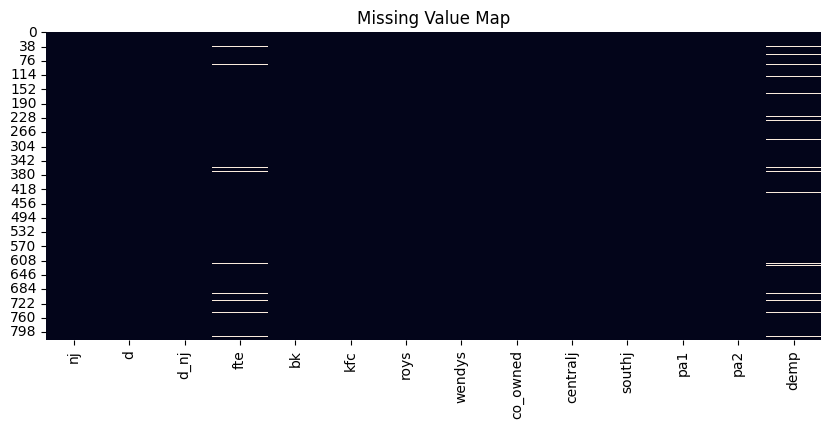

In [6]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Map")
plt.show()

In [7]:
total_rows = len(df)

missing_counts = df.isnull().sum()
missing_pct = (missing_counts / total_rows) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})

print(missing_summary)

          missing_count  missing_pct
nj                    0     0.000000
d                     0     0.000000
d_nj                  0     0.000000
fte                  26     3.170732
bk                    0     0.000000
kfc                   0     0.000000
roys                  0     0.000000
wendys                0     0.000000
co_owned              0     0.000000
centralj              0     0.000000
southj                0     0.000000
pa1                   0     0.000000
pa2                   0     0.000000
demp                 52     6.341463


In [8]:
# I can drop fte because it is < 5% and it looks random from the 'Missing Value Map'.
# I cannot drop demp as it is > 5%, however it does look random. I have to report this as structural

# Step 2.3: Exploratory Data Analysis (EDA) as Visual Forensics

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


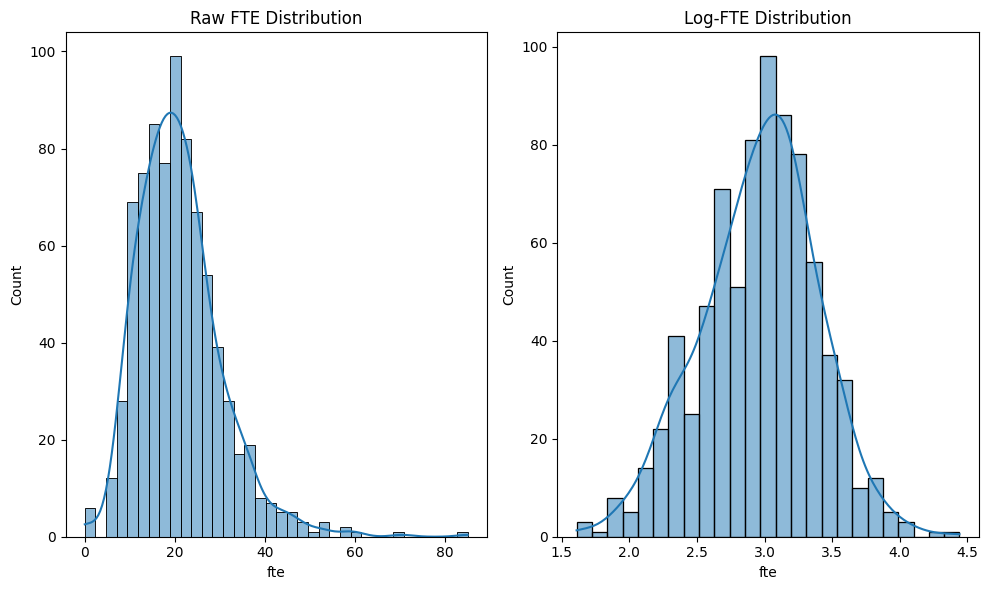

In [10]:
# Requirement 1: The Univariate Distribution (The "Money Illusion" Check)

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['fte'].dropna(), kde=True)
plt.title("Raw FTE Distribution")

plt.subplot(1, 2, 2)
sns.histplot(np.log(df['fte'].dropna()), kde=True)
plt.title("Log-FTE Distribution")

plt.tight_layout()
plt.show()

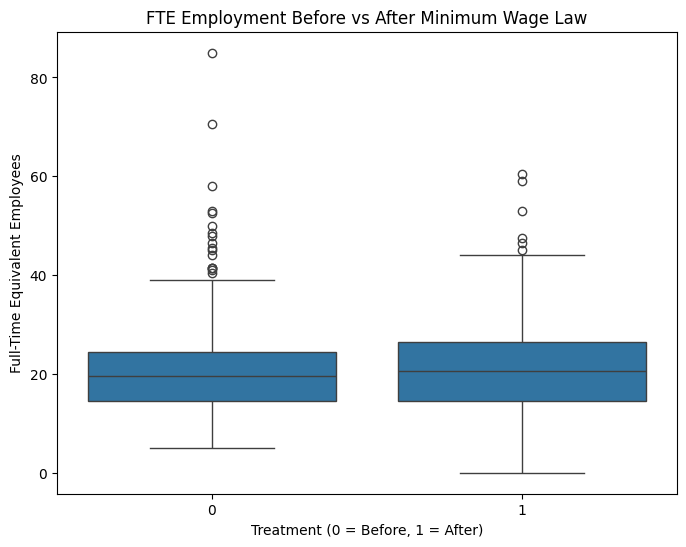

In [12]:
# Requirement 2: The Bivariate Relationship (The "Eyeball Test")
plt.figure(figsize=(8, 6))
sns.boxplot(x='d', y='fte', data=df)
plt.title("FTE Employment Before vs After Minimum Wage Law")
plt.xlabel("Treatment (0 = Before, 1 = After)")
plt.ylabel("Full-Time Equivalent Employees")
plt.show()

In [13]:
# Requirement 3: Outlier Detection (Robust Statistics)

Q1 = df['fte'].quantile(0.25)
Q3 = df['fte'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

Q1: 14.5
Q3: 25.5
IQR: 11.0
Lower Fence: -2.0
Upper Fence: 42.0


In [14]:
outliers = df[(df['fte'] < lower_fence) | (df['fte'] > upper_fence)]

print("Number of outliers:", len(outliers))
print("Percentage of data:", round((len(outliers) / len(df)) * 100, 2), "%")
print(outliers['fte'])

Number of outliers: 22
Percentage of data: 2.68 %
6      44.0
45     46.5
73     48.0
74     45.5
123    50.0
141    85.0
144    53.0
344    53.0
347    45.0
404    46.5
421    44.0
472    59.0
481    44.0
498    60.5
572    47.5
593    43.5
668    70.5
673    58.0
705    52.5
707    45.0
727    48.5
812    43.5
Name: fte, dtype: float64
